# Seaborn Concepts: Visualizing Data Distributions

Understanding how data is distributed is key to insightful analysis. Seaborn offers several powerful plot types specifically designed to visualize distributions, helping you uncover patterns, trends, and anomalies at a glance. Key distribution plots include:

* **distplot** — Combines a histogram with a kernel density estimate (KDE) for a detailed view of data distribution.
* **jointplot** — Displays bivariate distributions with scatterplots or hexbin plots alongside marginal histograms.
* **pairplot** — Generates pairwise relationships across an entire dataframe, perfect for multi-variable analysis.
* **rugplot** — Adds small vertical lines along the x-axis to represent individual data points.
* **kdeplot** — Provides a smooth estimate of the data’s probability density function.

___________

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2007/Session%2007_2%20-%20Advanced%20Matplotlib%20Concepts.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2007/Session%2007_2%20-%20Advanced%20Matplotlib%20Concepts.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

In [1]:
import seaborn as sns
%matplotlib inline

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 📊 Seaborn `histplot()`

`histplot()` is a **modern replacement** for the deprecated `distplot()` in Seaborn. It offers more flexibility and is part of the figure-level plotting API.

---

### 🎯 What is `histplot()`?

`histplot()` is used to **visualize the distribution** of a single variable (univariate) or the relationship between **two numeric variables** (bivariate), using **histograms**.

---

### ✨ Key Features of `histplot`

| Parameter        | Description |
|------------------|-------------|
| `data`           | DataFrame or array-like input data. |
| `x`, `y`         | The variable(s) to plot on the x/y-axis. |
| `bins`           | Number of histogram bins or bin edges (int, sequence, or "auto"). |
| `kde`            | If `True`, overlays a Kernel Density Estimate (KDE) curve. |
| `hue`            | Grouping variable that will produce multiple histograms. |
| `multiple`       | How to draw multiple elements: `"layer"`, `"stack"`, `"dodge"`, or `"fill"`. |
| `element`        | Visual representation: `"bars"` (default), `"step"`, `"poly"`. |
| `stat`           | Normalize bars: `"count"` (default), `"frequency"`, `"density"`, or `"probability"`. |
| `shrink`         | Scale width of bars (useful for dodged plots). |
| `discrete`       | If `True`, treats input data as discrete. |
| `palette`        | Color palette when `hue` is used. |
| `common_norm`    | Normalize across all groups if `hue` is used (default: True). |

---


### 🔄 Comparing KDE and Histogram

* `kde=True` adds a smooth curve representing the **probability density**.
* This helps understand the shape of the distribution beyond the histogram bars.

---

### 🧠 Tips for Usage

* Use `stat="density"` to compare distributions regardless of sample size.
* Use `multiple="fill"` to see **proportional comparison** between categories.

---

### 🧩 2D Histogram (Joint Distribution)

> 🚀 **Pro Tip:** Combine `histplot()` with `FacetGrid` or `displot()` for multi-panel plots based on category variables.


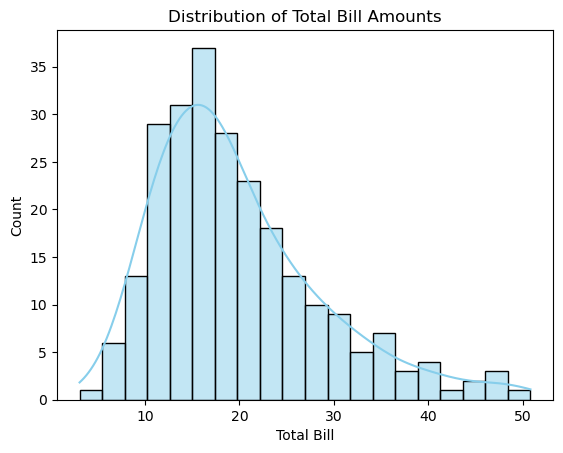

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sns.histplot(data=tips, x="total_bill", bins=20, kde=True, color="skyblue")

plt.title("Distribution of Total Bill Amounts")
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()

To remove the kde layer and just have the histogram use:

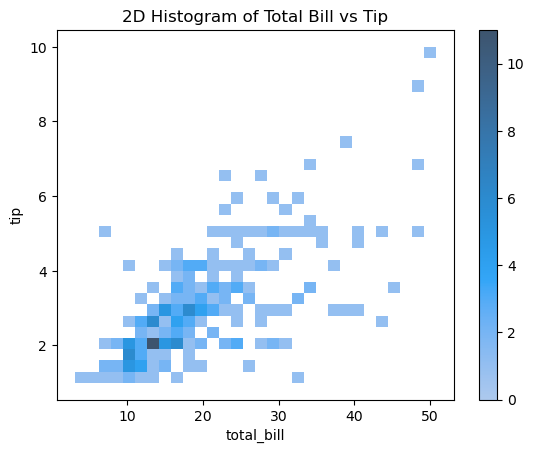

In [5]:
sns.histplot(data=tips, x="total_bill", y="tip", bins=30, cbar=True)

plt.title("2D Histogram of Total Bill vs Tip")
plt.show()

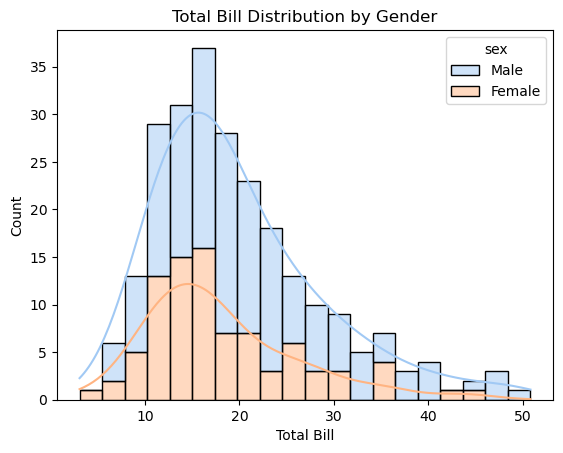

In [6]:
sns.histplot(data=tips, 
             x="total_bill", 
             hue="sex", 
             bins=20, 
             kde=True,
             multiple="stack", 
             palette="pastel")

plt.title("Total Bill Distribution by Gender")
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()

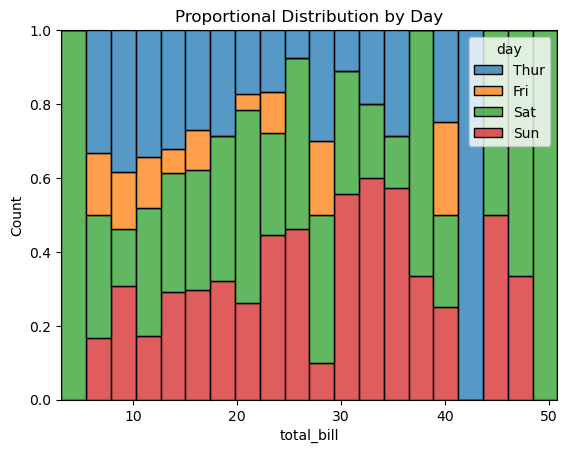

In [7]:
sns.histplot(data=tips, 
             x="total_bill", 
             hue="day", 
             multiple="fill", 
             bins=20)

plt.title("Proportional Distribution by Day")
plt.show()

## 🔗 Seaborn `jointplot()` — Bivariate Relationship Visualization

`jointplot()` is a powerful **figure-level function** in Seaborn that combines:

- A **scatter plot**, **regression**, or **kde plot** in the center
- With **univariate distributions** (histograms or KDEs) on the top and right margins

---

### 🎯 What is `jointplot()`?

It’s ideal for analyzing relationships between **two numeric variables**, while also showing their **individual distributions**.

---

### ✨ Key Parameters of `jointplot()`

| Parameter     | Description |
|---------------|-------------|
| `data`        | DataFrame containing the variables. |
| `x`, `y`      | Names of the variables to compare. |
| `kind`        | Type of plot: `"scatter"` (default), `"kde"`, `"hist"`, `"hex"`, `"reg"`, `"resid"`. |
| `hue`         | Categorical variable for color grouping. |
| `palette`     | Color palette when using `hue`. |
| `height`      | Size (in inches) of each side of the figure. |
| `ratio`       | Ratio of joint axes size to marginal axes. |
| `space`       | Space between the joint and marginal plots. |
| `marginal_kws`| Additional kwargs for marginal plots. |
| `joint_kws`   | Additional kwargs for the joint plot. |

---


> 🧠 **Pro Tip:** For categorical comparison or complex layouts, use `hue` with KDE plots or explore `FacetGrid` for multiplot panels.


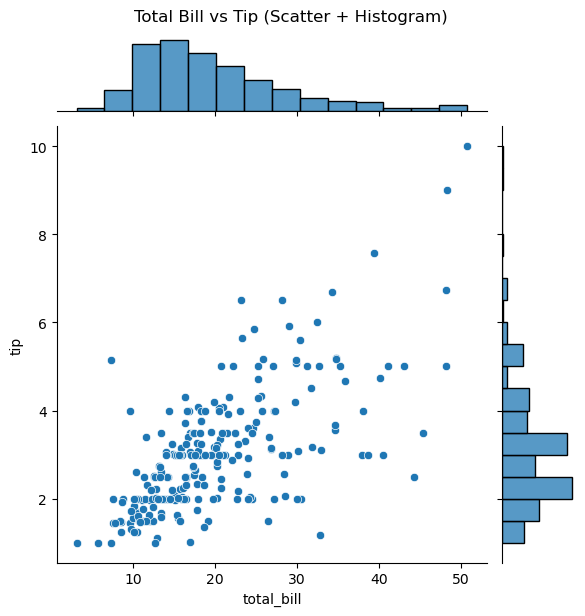

In [8]:
sns.jointplot(data=tips, x="total_bill", y="tip")

plt.suptitle("Total Bill vs Tip (Scatter + Histogram)", y=1.02)
plt.show()

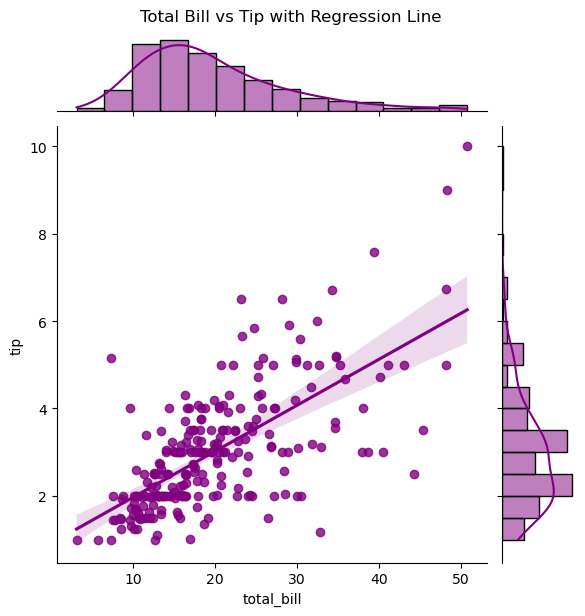

In [9]:
sns.jointplot(data=tips, 
              x="total_bill", 
              y="tip", 
              kind="reg", 
              color="purple")

plt.suptitle("Total Bill vs Tip with Regression Line", y=1.02)
plt.show()

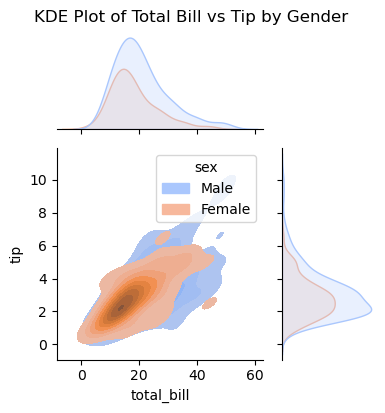

In [10]:
sns.jointplot(data=tips, 
              x="total_bill", 
              y="tip", 
              hue="sex", 
              kind="kde", 
              fill=True, 
              palette="coolwarm", height=4,ratio=2)

plt.suptitle("KDE Plot of Total Bill vs Tip by Gender", y=1.02)
plt.show()

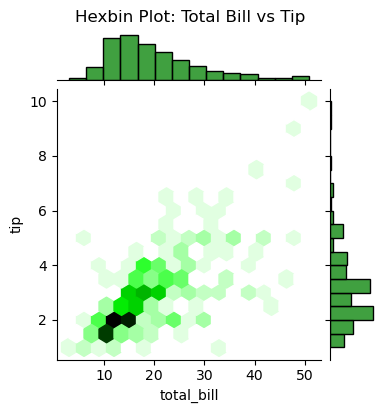

In [11]:
sns.jointplot(data=tips, 
              x="total_bill", 
              y="tip", 
              kind="hex", 
              color="green",height=4)

plt.suptitle("Hexbin Plot: Total Bill vs Tip", y=1.02)
plt.show()

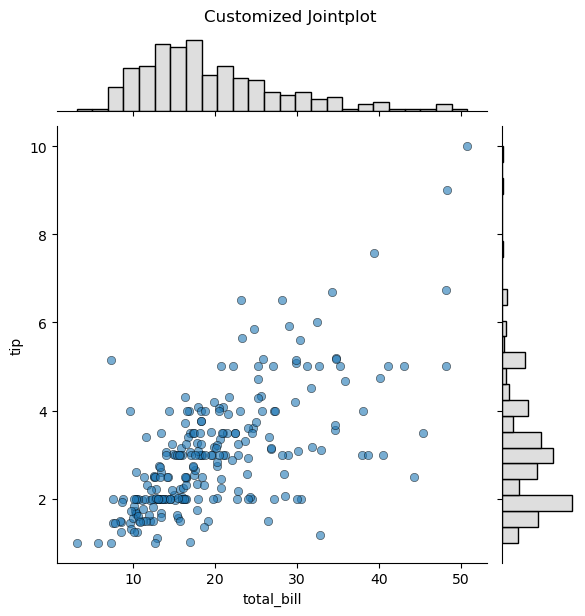

In [12]:
sns.jointplot(data=tips,
              x="total_bill",
              y="tip",
              kind="scatter",
              marginal_kws=dict(bins=25, fill=True, color='lightgray'),
              joint_kws=dict(alpha=0.6, edgecolor='black'))

plt.suptitle("Customized Jointplot", y=1.02)
plt.show()

## 🔗 Seaborn `pairplot()` — Visualizing Pairwise Relationships

`pairplot()` is a powerful figure-level function in Seaborn used to explore **pairwise relationships** across an entire **DataFrame**. It creates a matrix of plots, making it easy to spot correlations, trends, and distributions.

---

### 🎯 What is `pairplot()`?

- It plots **every numeric variable** in a dataset against every other one.
- Diagonal: Shows **univariate distributions** (histogram or KDE).
- Off-diagonal: Shows **bivariate relationships** (usually scatter plots).

---

### ✨ Key Parameters of `pairplot()`

| Parameter     | Description |
|---------------|-------------|
| `data`        | DataFrame containing the variables. |
| `hue`         | Categorical variable for color grouping. |
| `palette`     | Color palette for different hue levels. |
| `kind`        | Type of plot for off-diagonal: `"scatter"` (default) or `"kde"`. |
| `diag_kind`   | Type of plot on diagonal: `"auto"` (default), `"hist"`, or `"kde"`. |
| `markers`     | Marker styles for different levels of hue. |
| `corner`      | If `True`, don’t plot upper triangle (less clutter). |
| `plot_kws`    | Dict of keyword args for off-diagonal plots. |
| `diag_kws`    | Dict of keyword args for diagonal plots. |
| `height`      | Size (in inches) of **each subplot**. |
| `aspect`      | Aspect ratio of each subplot. |


---

### 🔧 How to Change Figure Size in `pairplot()`

Unlike `histplot()`, `pairplot()` does **not use** `plt.figure(figsize=(...))`.

Instead, control the size using:

* `height`: size of each subplot in inches
* `aspect`: width/height ratio

---

> 📌 **Pro Tip:** Use `corner=True` for large datasets to reduce visual clutter and focus on the most relevant relationships.

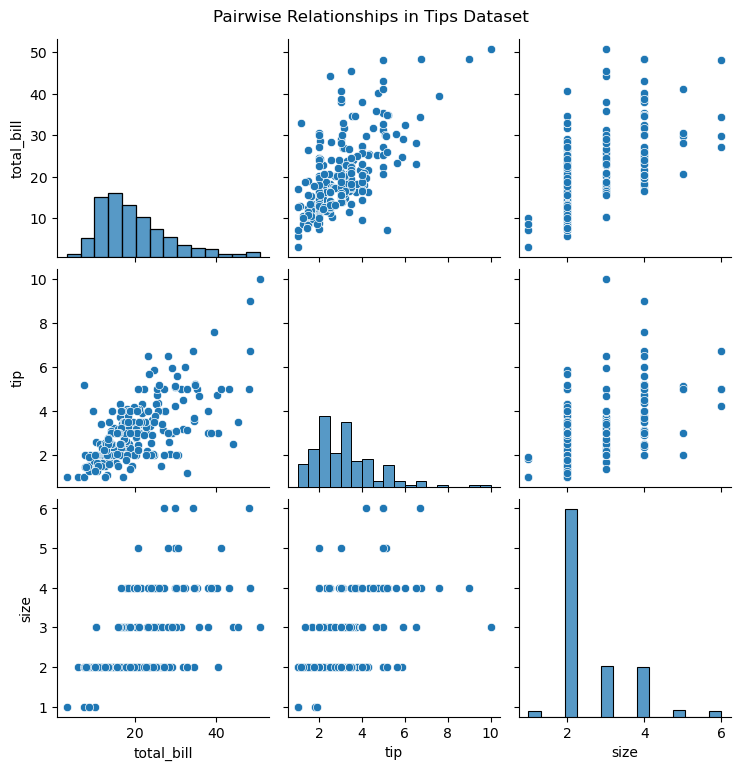

In [13]:
sns.pairplot(data=tips)

plt.suptitle("Pairwise Relationships in Tips Dataset", y=1.02)
plt.show()

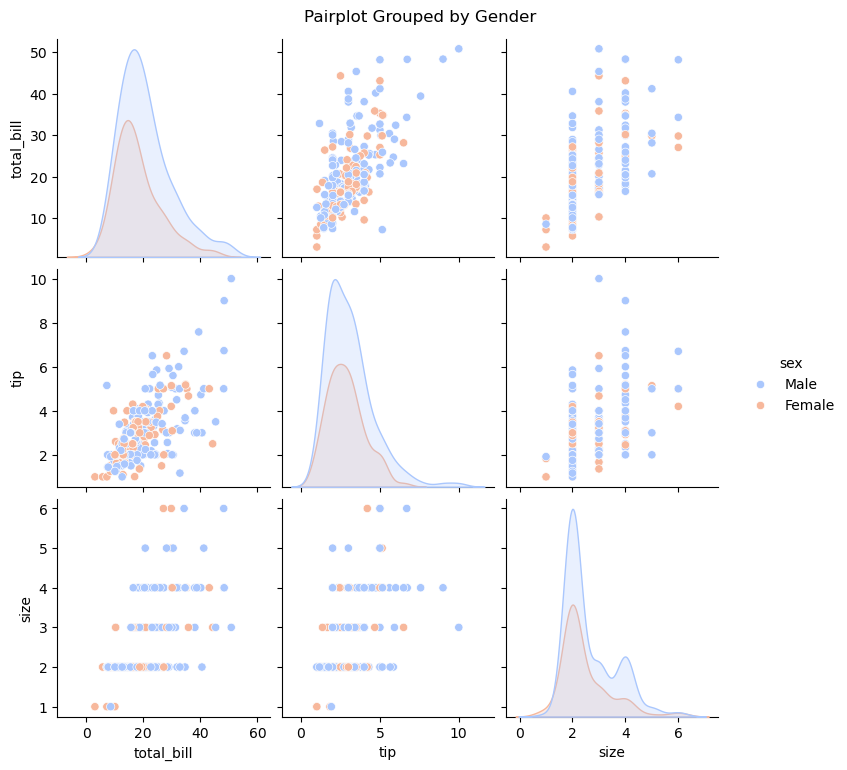

In [15]:
sns.pairplot(data=tips, hue="sex", palette="coolwarm")

plt.suptitle("Pairplot Grouped by Gender", y=1.02)
plt.show()

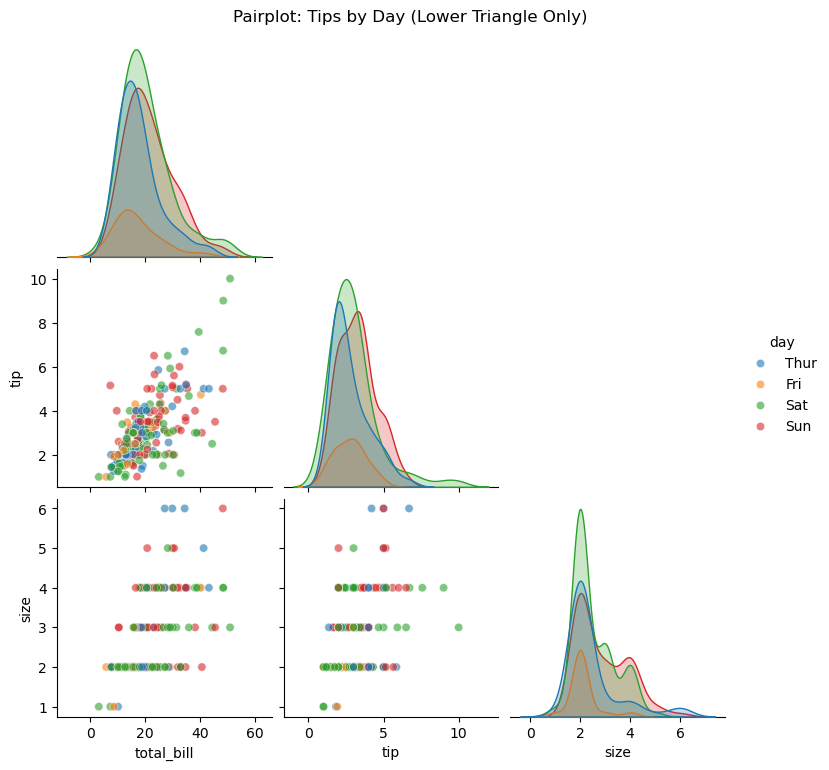

In [16]:
sns.pairplot(
    data=tips,
    hue="day",
    diag_kind="kde",   # use KDE on diagonal
    kind="scatter",    # scatter on off-diagonal
    corner=True,       # only lower triangle
    plot_kws={'alpha': 0.6}
)

plt.suptitle("Pairplot: Tips by Day (Lower Triangle Only)", y=1.02)
plt.show()

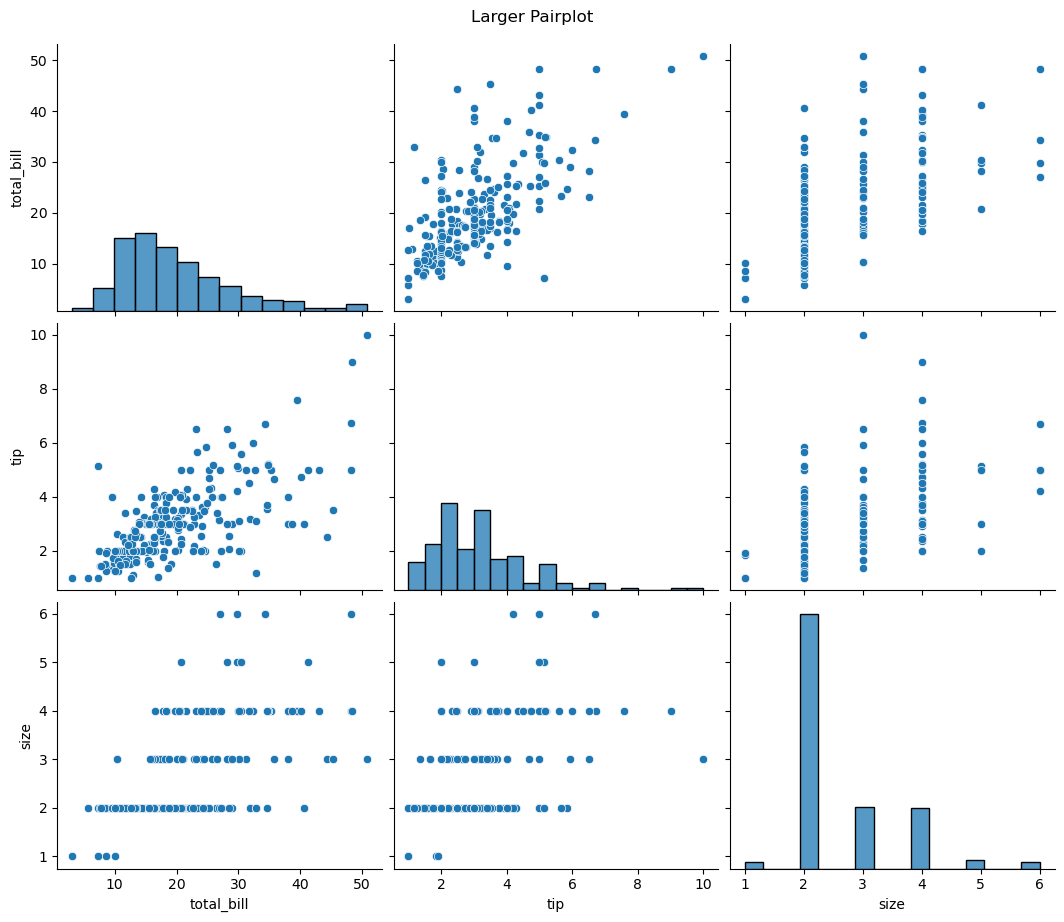

In [14]:
sns.pairplot(data=tips, height=3, aspect=1.2)
plt.suptitle("Larger Pairplot", y=1.02)
plt.show()

## 📏 Seaborn `rugplot()` — Mini Distribution Markers

A **rug plot** is a simple visualization that adds **small vertical ticks** (or dashes) along the x-axis to show individual data points. It's often used to complement histograms or KDE plots by giving a sense of the **raw distribution**.

---

### 🎯 What is `rugplot()` Used For?

- Displays **raw data distribution** on an axis.
- Useful for highlighting **data density**, **clustering**, or **outliers**.
- Often combined with histograms or KDE plots for richer context.

---

### ✨ Unique Parameters in `rugplot()`

| Parameter     | Description |
|---------------|-------------|
| `height`      | Length of the rug lines (as a proportion of the axis). |
| `expand_margins` | Whether to add margin space to accommodate rug lines (default: `True`). |
| `linewidth`   | Width of each tick mark. |
| `alpha`       | Transparency of the rug lines. |
| `clip_on`     | Whether rug lines are clipped to the plot area. |

---

> 🧠 **Pro Tip:** Avoid using rug plots with **very large datasets** — they clutter the axis and reduce clarity.


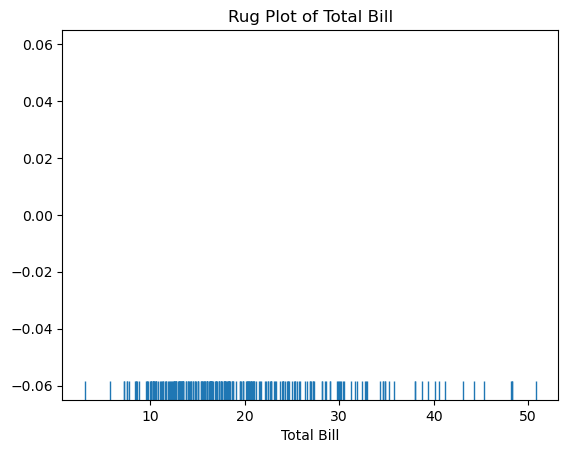

In [17]:
sns.rugplot(data=tips, x="total_bill", height=0.05)

plt.title("Rug Plot of Total Bill")
plt.xlabel("Total Bill")
plt.show()

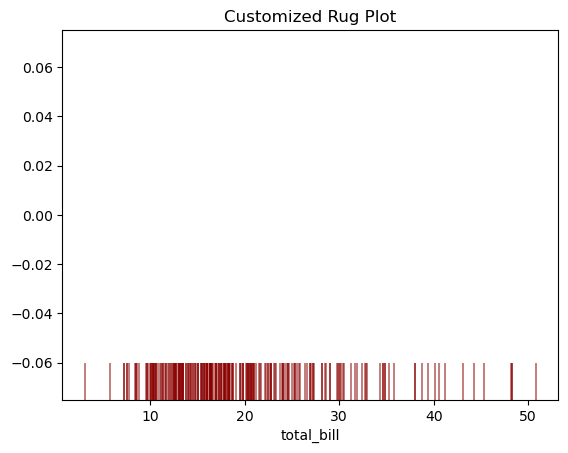

In [18]:
sns.rugplot(
    data=tips,
    x="total_bill",
    height=0.1,
    linewidth=1.2,
    alpha=0.6,
    color="darkred",
)

plt.title("Customized Rug Plot")
plt.show()

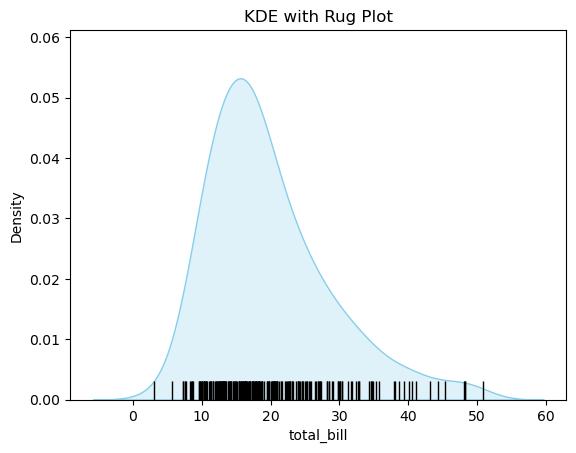

In [22]:
sns.kdeplot(data=tips, x="total_bill", fill=True, color="skyblue")
sns.rugplot(data=tips, x="total_bill", color="black", height=0.05)

plt.title("KDE with Rug Plot")
plt.show()

## 🌊 Seaborn `kdeplot()` — Smooth Distribution Visualization

`kdeplot()` stands for [Kernel Density Estimation plots](https://fa.wikipedia.org/wiki/%D8%A8%D8%B1%D8%A2%D9%88%D8%B1%D8%AF_%DA%86%DA%AF%D8%A7%D9%84%DB%8C)., a tool to visualize the **probability density function (PDF)** of a continuous variable. It provides a smooth curve that represents the distribution of the data — a smoothed version of a histogram.

---

### 🎯 What Does `kdeplot()` Show?

- A **smooth estimate** of the **underlying distribution** of a dataset.
- Helps you understand:
  - Central tendency (where values are concentrated)
  - Spread (how wide the data is)
  - Skewness and modality (single peak, multiple peaks)

Unlike histograms that depend on **bin sizes**, KDEs are **continuous**, offering a more refined view of the data.

> 📌 It is **ideal for continuous data** (e.g., prices, measurements). Avoid using KDE for categorical or highly discrete variables.

---

### ✨ Unique Parameters in `kdeplot()`

| Parameter      | Description |
|----------------|-------------|
| `bw_adjust`    | Bandwidth adjustment — controls smoothness. Higher = smoother. |
| `fill`         | If `True`, fills the area under the curve. |
| `common_norm`  | Normalize KDE across groups when using `hue` (default: `True`). |
| `multiple`     | For multiple KDEs: `"layer"`, `"stack"`, `"fill"` |
| `cut`          | How far to extend the KDE beyond data limits (default: 3). |
| `clip`         | Restrict KDE to a range, e.g., `clip=(0, 100)`. |
| `cumulative`   | If `True`, plots cumulative distribution function (CDF). |
| `bw_method`    | Alternative to `bw_adjust`, same as in `scipy.stats.gaussian_kde`. |
| `thresh`       | Minimum value to display in a filled KDE. |
| `gridsize`     | Number of points in the KDE grid (higher = smoother). |

---

> 📌 **Pro Tip:** Use `bw_adjust=0.5` to **increase detail** (less smoothing) or `bw_adjust=2` to **reduce noise**.

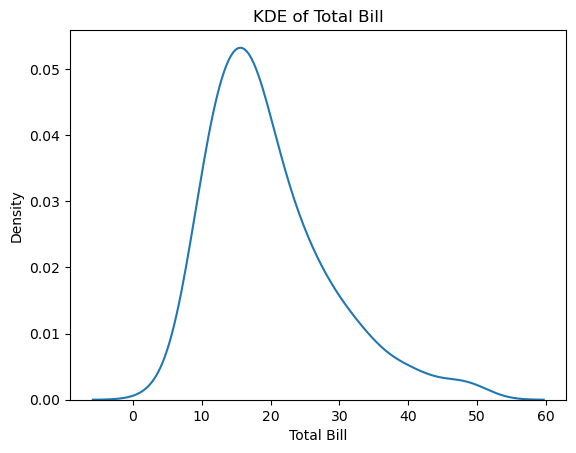

In [23]:
sns.kdeplot(data=tips, x="total_bill")

plt.title("KDE of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.show()

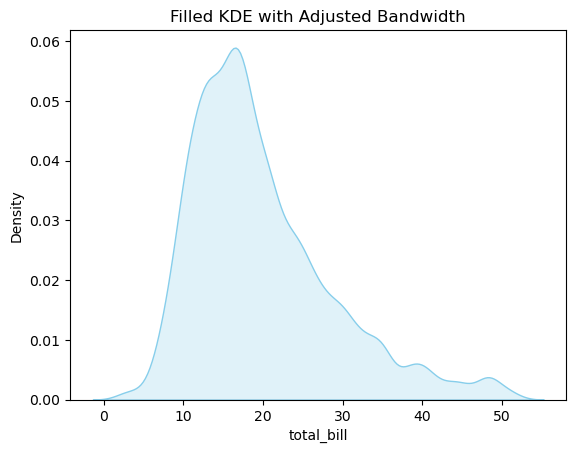

In [24]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    fill=True,
    color="skyblue",
    bw_adjust=0.5  # lower = more detailed
)

plt.title("Filled KDE with Adjusted Bandwidth")
plt.show()

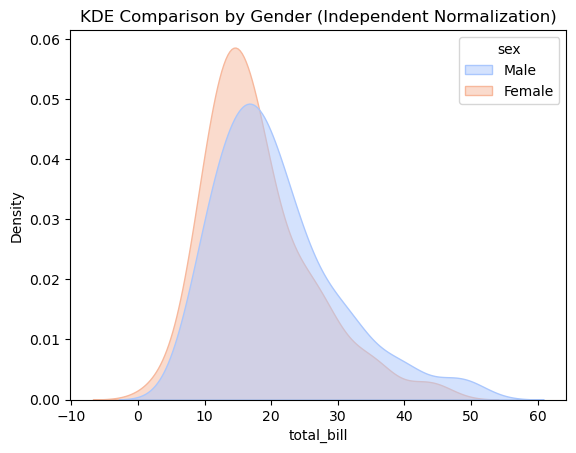

In [25]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="sex",
    fill=True,
    common_norm=False,
    palette="coolwarm",
    alpha=0.5
)

plt.title("KDE Comparison by Gender (Independent Normalization)")
plt.show()

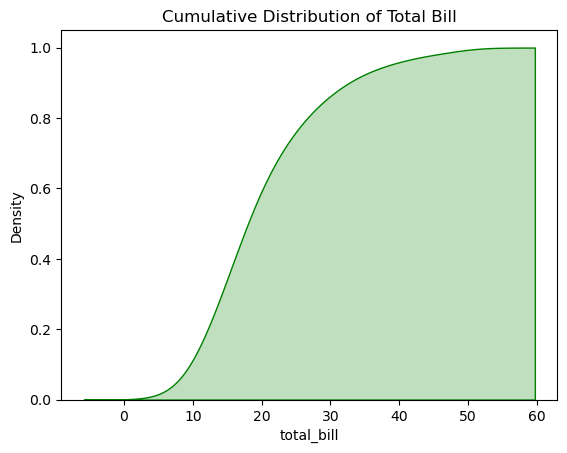

In [26]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    fill=True,
    cumulative=True,
    color="green"
)

plt.title("Cumulative Distribution of Total Bill")
plt.show()

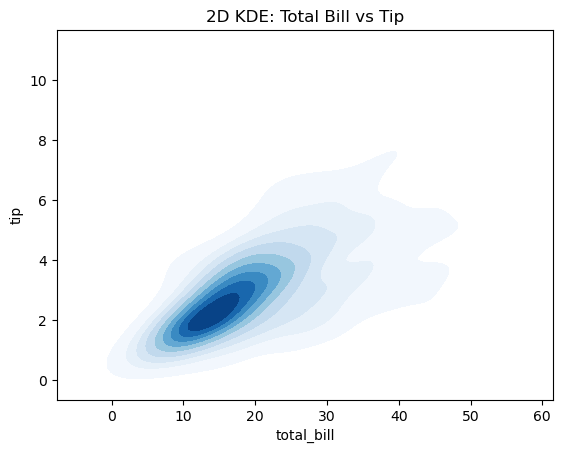

In [27]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    y="tip",
    fill=True,
    cmap="Blues"
)

plt.title("2D KDE: Total Bill vs Tip")
plt.show()

## 📊 `seaborn.lmplot()`

`seaborn.lmplot()` is a powerful function for drawing **linear regression models**. It’s built on **FacetGrid** and is ideal for plotting **regression relationships** across subsets of your data.

---

### 🧠 When to Use `lmplot()`

Use `lmplot()` when:

* You want to **plot linear regression lines** with confidence intervals.
* You want to **compare regression lines across groups**.
* You need to **facet the plot** across multiple columns or rows.

---


| Parameter     | Description                              |
| ------------- | ---------------------------------------- |
| `x`, `y`      | Variables to plot                        |
| `hue`         | Grouping variable for color              |
| `palette`     | Color palette                            |
| `col`, `row`  | Subplot faceting                         |
| `markers`     | Marker styles for groups                 |
| `ci`          | Confidence interval for regression line  |
| `fit_reg`     | Toggle regression line                   |
| `height`      | Height (in inches) of each facet         |
| `aspect`      | Width = `height * aspect`                |
| `scatter_kws` | Dict of keyword args for scatter plot    |
| `line_kws`    | Dict of keyword args for regression line |



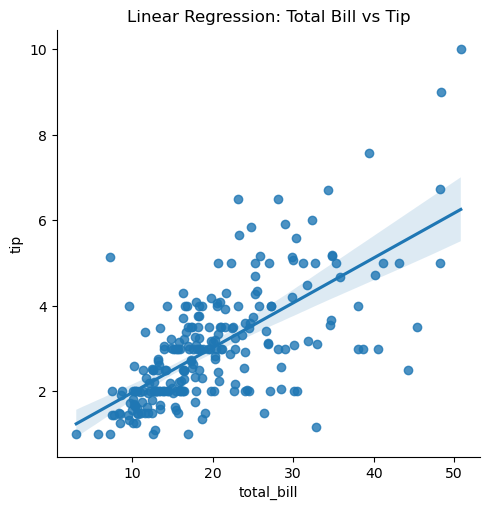

In [28]:
sns.lmplot(x="total_bill", y="tip", data=tips)
plt.title("Linear Regression: Total Bill vs Tip")
plt.show()

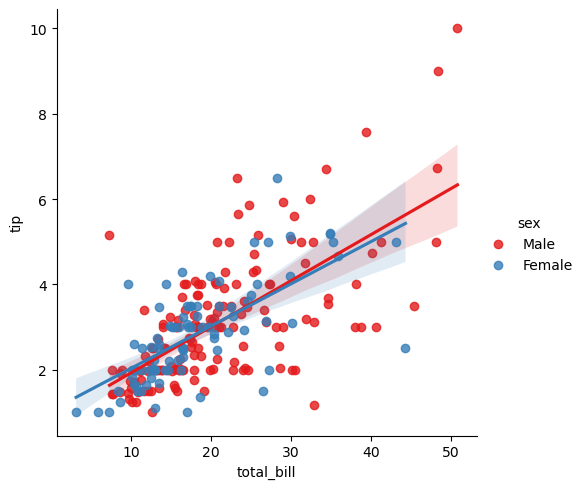

In [31]:
sns.lmplot(x="total_bill", y="tip", hue="sex", data=tips, palette="Set1")
plt.show()

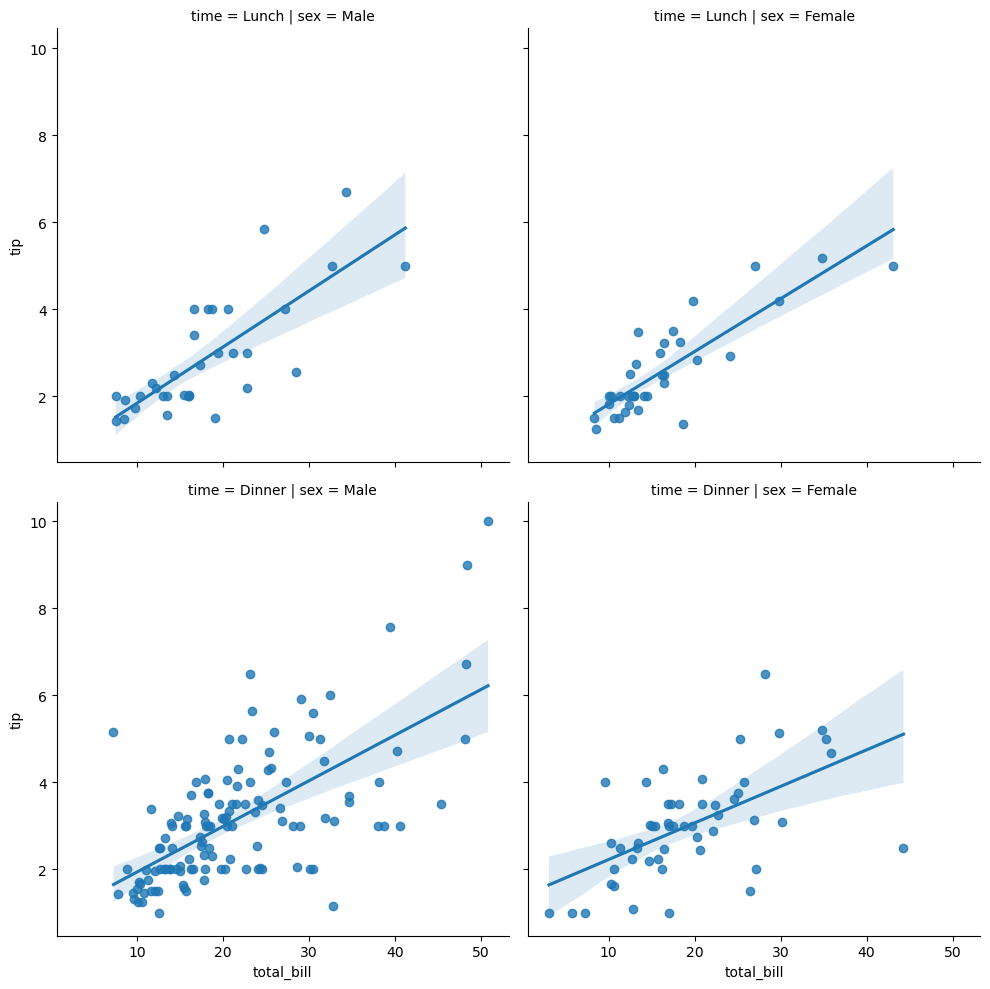

In [32]:
sns.lmplot(x="total_bill", y="tip", col="sex", row="time", data=tips)
plt.show()

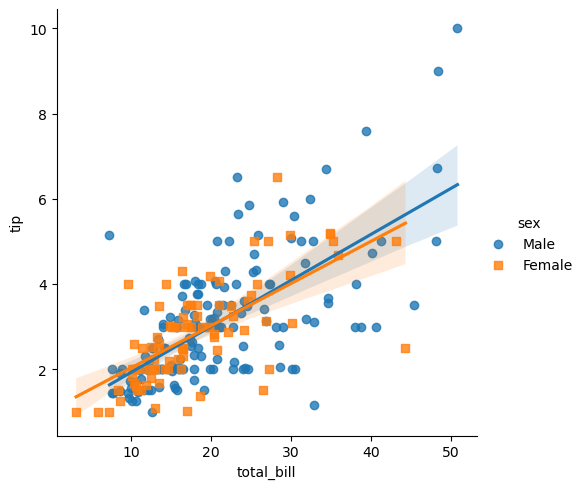

In [35]:
sns.lmplot(x="total_bill", y="tip", hue="sex", data=tips,
           markers=["o", "s"])
plt.show()

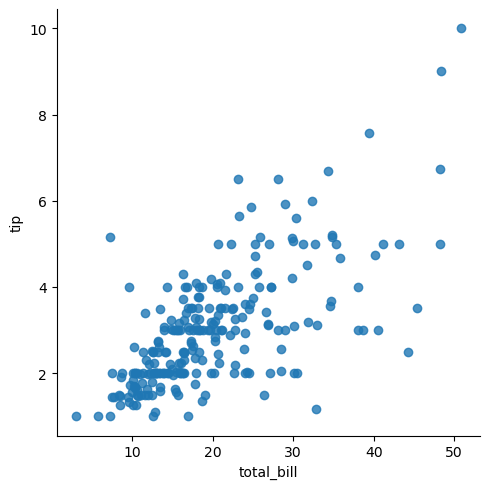

In [37]:
sns.lmplot(x="total_bill", y="tip", data=tips, fit_reg=False)
plt.show()

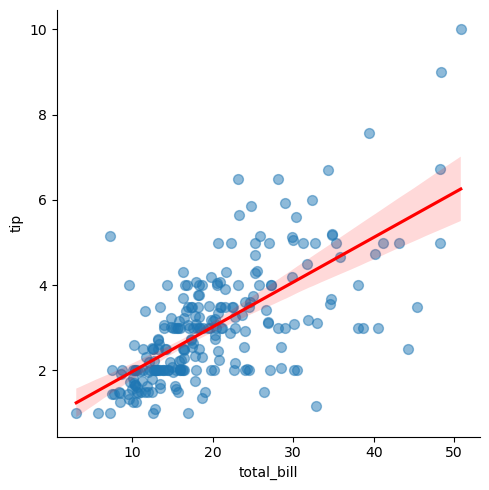

In [38]:
sns.lmplot(x="total_bill", y="tip", data=tips,
           scatter_kws={'s': 50, 'alpha': 0.5},
           line_kws={'color': 'red'})
plt.show()

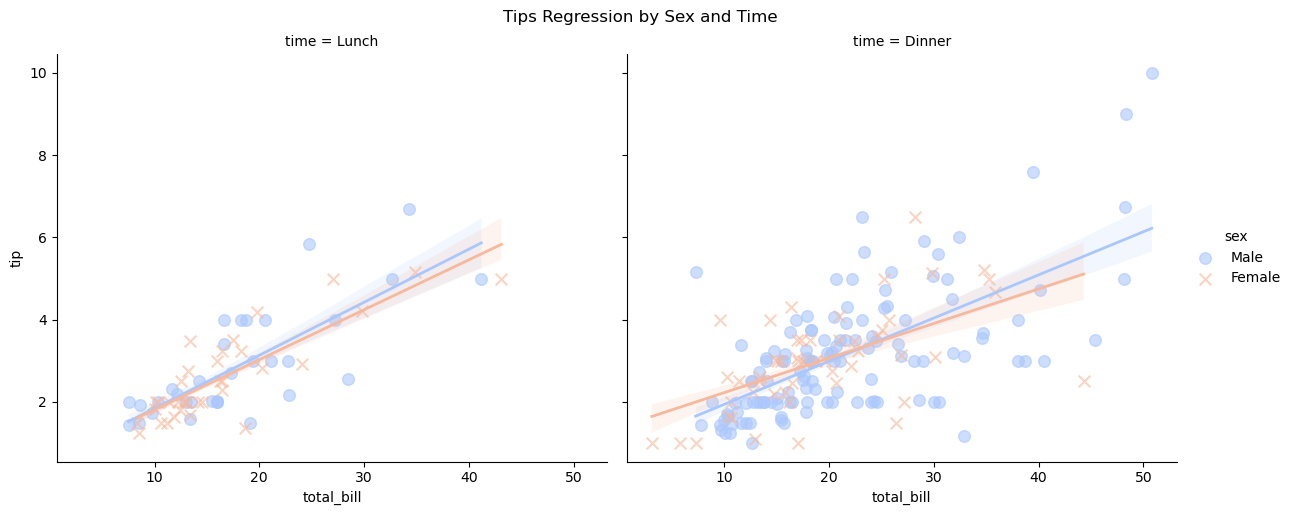

In [36]:
sns.lmplot(
    x="total_bill",
    y="tip",
    data=tips,
    hue="sex",
    col="time",
    palette="coolwarm",
    markers=["o", "x"],
    height=5,
    aspect=1.2,
    ci=68,
    scatter_kws={"s": 70, "alpha": 0.6},
    line_kws={"linewidth": 2}
)
plt.suptitle("Tips Regression by Sex and Time", y=1.02)
plt.show()

# Great Job!


<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     "
     onmouseover="this.style.backgroundColor='#2f3a52';"
     onmouseout="this.style.backgroundColor='#414f6f';">
    ▶️ Next
  </a>
</div>